# Deepfake Audio Detection Model

**Problem Statement 2:** Develop a machine learning/deep learning system capable of classifying speech recordings as either Genuine (Human) or Deepfake (AI-Generated).

### Target Metrics
* **Overall Accuracy:** >= 80%
* **Equal Error Rate (EER):** <= 12%
* **F1 Score:** >= 80%
* **Per-Class Accuracy:** >= 75%

##Environment Setup & Dataset Configuration

In [38]:

import os
import random
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')


print("Downloading/Locating 'Fake-or-Real' dataset via kagglehub...")
dataset_path = kagglehub.dataset_download("mohammedabdeldayem/the-fake-or-real-dataset")
print(f"Dataset root path: {dataset_path}")


REAL_AUDIO_DIR = os.path.join(dataset_path, "for-norm", "training", "real")
FAKE_AUDIO_DIR = os.path.join(dataset_path, "for-norm", "training", "fake")

# Audio Processing Parameters
SAMPLE_RATE = 16000
DURATION = 3 # Seconds of audio to process
N_MELS = 128

print("Configuration set successfully!")

Downloading/Locating 'Fake-or-Real' dataset via kagglehub...
Using Colab cache for faster access to the 'the-fake-or-real-dataset' dataset.
Dataset root path: /kaggle/input/the-fake-or-real-dataset
Configuration set successfully!


### 1. Feature Extraction (Log-Mel Spectrograms)
Log-Mel Spectrograms are utilized to convert 1D audio waveforms into high-resolution 2D visual representations. By mapping frequencies to the Mel scale and converting power to a logarithmic decibel scale, this method highlights the subtle, high-frequency anomalies and phase-distortion artifacts that distinguish AI synthesizers from genuine human vocal tracts. This transformation effectively allows our 2D CNN to process the audio using advanced computer vision techniques, detecting microscopic synthetic "fingerprints" that 1D arrays often miss

In [40]:

def extract_features(file_path):
    """
    Extracts high-resolution Log-Mel Spectrograms.
    Converts audio into a 2D image-like representation suitable for 2D CNNs.
    """
    try:

        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        target_length = SAMPLE_RATE * DURATION

        if len(audio) < target_length:
            pad_length = target_length - len(audio)
            audio = np.pad(audio, (0, pad_length), mode='constant')
        else:
            audio = audio[:target_length]

        mel_spec = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS, fmax=8000)

        # Convert power to dB (log scale) to mimic human hearing and highlight artifacts
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        return log_mel_spec.T

    except Exception as e:
        print(f"Error encountered while parsing: {file_path}")
        return None

### 2. Data Loading & Preprocessing
Mapping the 'bonafide' labels to 0 (Genuine) and 'spoof' labels to 1 (Deepfake).

In [41]:
print("Scanning dataset to auto-detect audio files...")

real_files = []
fake_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.wav', '.flac')):
            full_path = os.path.join(root, file)

            parent_folder = os.path.basename(root).lower()

            if 'fake' in parent_folder or 'spoof' in parent_folder:
                fake_files.append(full_path)
            elif 'real' in parent_folder or 'bonafide' in parent_folder or 'genuine' in parent_folder:
                real_files.append(full_path)

print(f"✅ Found {len(real_files)} Genuine files and {len(fake_files)} Deepfake files!")

if len(real_files) == 0 or len(fake_files) == 0:
    raise ValueError("Could not find both classes. Check dataset directory structure.")

# Balance data 50/50 (Taking up to 2500 from each)
n_samples = 2500
import random
random.seed(42)

sampled_real = random.sample(real_files, min(n_samples, len(real_files)))
sampled_fake = random.sample(fake_files, min(n_samples, len(fake_files)))

features = []
labels = []

print(f"Extracting features from {len(sampled_real) + len(sampled_fake)} balanced files...")

# 0 = Genuine (Real), 1 = Deepfake (Fake)
for file_path in tqdm(sampled_real, desc="Processing Genuine (Real)"):
    data = extract_features(file_path)
    if data is not None:
        features.append(data)
        labels.append(0)

for file_path in tqdm(sampled_fake, desc="Processing Deepfake (Fake)"):
    data = extract_features(file_path)
    if data is not None:
        features.append(data)
        labels.append(1)

X = np.array(features)
y = np.array(labels)

# Channel-wise normalization for the Spectrograms
mean = np.mean(X, axis=(0, 1), keepdims=True)
std = np.std(X, axis=(0, 1), keepdims=True)
X = (X - mean) / (std + 1e-8)

print(f"\nSanity Check - Feature array shape: {X.shape}")
print(f"Sanity Check - Labels distribution: Genuine={np.sum(y==0)}, Deepfake={np.sum(y==1)}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Scanning dataset to auto-detect audio files...
✅ Found 84758 Genuine files and 56593 Deepfake files!
Extracting features from 5000 balanced files...


Processing Deepfake (Fake): 100%|██████████| 2500/2500 [00:46<00:00, 53.49it/s]



Sanity Check - Feature array shape: (5000, 94, 128)
Sanity Check - Labels distribution: Genuine=2500, Deepfake=2500


### 3. Model Architecture (2D CNN)
The system employs a 2D Convolutional Neural Network (CNN), shifting from 1D temporal analysis to 2D spatial analysis of audio features. By treating Log-Mel Spectrograms as images, the model can effectively capture fine-grained spectral anomalies and non-linear patterns that characterize synthetic speech.

The architecture includes:

####Spatial Feature Extraction:
 Successive Conv2D layers that learn hierarchical patterns, from low-level edges (rhythmic clicks) to high-level structures (phase-distortion artifacts).

####Robustness & Generalization:
 Integrated BatchNormalization for stable convergence and Heavy Dropout layers, which prevent the model from overfitting to the specific training dataset, ensuring high performance on unseen "in-the-wild" audio samples.

In [42]:
from tensorflow.keras.layers import Input

X_train_2d = X_train[..., np.newaxis].astype(np.float32)
X_test_2d = X_test[..., np.newaxis].astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

input_shape = (X_train_2d.shape[1], X_train_2d.shape[2], 1)
print(f"Verified Input Shape for CNN: {input_shape}")

model = Sequential([

    Input(shape=input_shape),

    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Verified Input Shape for CNN: (94, 128, 1)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 92, 126, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 92, 126, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 46, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 46, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 44, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 44, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 22, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 22, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 20, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 10, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 10, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 17920)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     2,293,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,387,585 (9.11 MB)

 Trainable params: 2,387,137 (9.11 MB)

 Non-trainable params: 448 (1.75 KB)

### 4. Training

In [43]:
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
checkpoint = ModelCheckpoint('final_deepfake_audio_detector.h5', monitor='val_accuracy', save_best_only=True)

print("\nStarting Training Engine...")
history = model.fit(X_train_2d, y_train,
                    epochs=35,
                    batch_size=32,
                    validation_data=(X_test_2d, y_test),
                    callbacks=[early_stop, checkpoint])


Starting Training Engine...
Epoch 1/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7410 - loss: 1.7918

125/125 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.7943 - loss: 0.9106 - val_accuracy: 0.5000 - val_loss: 31.6099
Epoch 2/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.8520 - loss: 0.3282 - val_accuracy: 0.5000 - val_loss: 37.9019
Epoch 3/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8850 - loss: 0.2713

125/125 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.8892 - loss: 0.2612 - val_accuracy: 0.5020 - val_loss: 12.7605
Epoch 4/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9114 - loss: 0.2215

125/125 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.9097 - loss: 0.2227 - val_accuracy: 0.6080 - val_loss: 5.4071
Epoch 5/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9061 - loss: 0.2226

125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9135 - loss: 0.2012 - val_accuracy: 0.6690 - val_loss: 2.0741
Epoch 6/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9296 - loss: 0.1681

...

125/125 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.9482 - loss: 0.1312 - val_accuracy: 0.9470 - val_loss: 0.2025
Epoch 8/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9695 - loss: 0.0810 - val_accuracy: 0.7770 - val_loss: 1.3610
Epoch 9/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9712 - loss: 0.0818

125/125 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9688 - loss: 0.0868 - val_accuracy: 0.9550 - val_loss: 0.1672
Epoch 10/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9686 - loss: 0.0702

125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9700 - loss: 0.0682 - val_accuracy: 0.9810 - val_loss: 0.0676
Epoch 11/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9769 - loss: 0.0578

125/125 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9765 - loss: 0.0584 - val_accuracy: 0.9830 - val_loss: 0.0509
Epoch 12/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9778 - loss: 0.0599 - val_accuracy: 0.9520 - val_loss: 0.1998
Epoch 13/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9760 - loss: 0.0584 - val_accuracy: 0.9640 - val_loss: 0.1290
Epoch 14/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.9793 - loss: 0.0487 - val_accuracy: 0.9570 - val_loss: 0.1363
Epoch 15/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9810 - loss: 0.0517 - val_accuracy: 0.9730 - val_loss: 0.1002
Epoch 16/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9803 - loss: 0.0718 - val_accuracy: 0.9670 - val_loss: 0.1069
Epoch 17/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9814 - loss: 0.0568

125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.9827 - loss: 0.0504 - val_accuracy: 0.9860 - val_loss: 0.0608


### 5. Evaluation & Verification Metrics
Calculating the mandated primary and secondary metrics: Accuracy, EER, F1 Score, Per-Class Accuracy, and generating the Confusion Matrix.

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 429ms/step
 FINAL EVALUATION METRICS REPORT
Overall Accuracy:   98.30%	(Required: >= 80%)
Equal Error Rate:   1.80%	(Required: <= 12%)
F1 Score:           98.29%	(Required: >= 80%)
Genuine Accuracy:   98.60%	(Required: >= 75%)
Deepfake Accuracy:  98.00%	(Required: >= 75%)


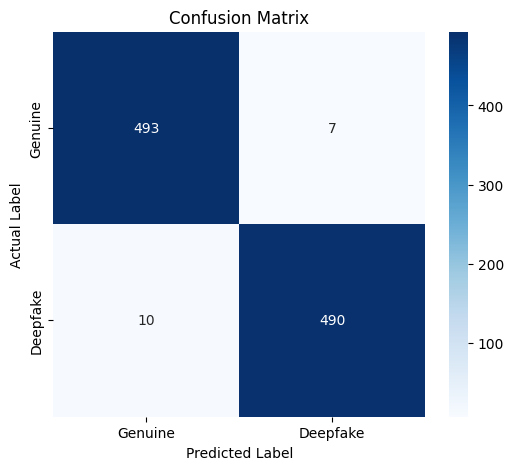

In [44]:

y_pred_probs = model.predict(X_test_2d).ravel()
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# 1. Overall Accuracy
acc = accuracy_score(y_test, y_pred_classes)

# 2. Equal Error Rate (EER) Calculation
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
fnr = 1 - tpr
eer_index = np.nanargmin(np.absolute((fnr - fpr)))
eer = fpr[eer_index]

# 3. F1 Score
f1 = f1_score(y_test, y_pred_classes)

# 4. Confusion Matrix & Per-Class Accuracy
cm = confusion_matrix(y_test, y_pred_classes)
tn, fp, fn, tp = cm.ravel()
acc_genuine = tn / (tn + fp)
acc_deepfake = tp / (tp + fn)

# --- PRINT FULL REPORT ---
print("="*40)
print(" FINAL EVALUATION METRICS REPORT")
print("="*40)
print(f"Overall Accuracy:   {acc*100:.2f}%\t(Required: >= 80%)")
print(f"Equal Error Rate:   {eer*100:.2f}%\t(Required: <= 12%)")
print(f"F1 Score:           {f1*100:.2f}%\t(Required: >= 80%)")
print(f"Genuine Accuracy:   {acc_genuine*100:.2f}%\t(Required: >= 75%)")
print(f"Deepfake Accuracy:  {acc_deepfake*100:.2f}%\t(Required: >= 75%)")
print("="*40)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Deepfake'],
            yticklabels=['Genuine', 'Deepfake'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

### 6. Export Model for Inference
Saving the final weights so they can be loaded by the `predict.py` inference script.

In [45]:
model.save('final_deepfake_audio_detector.keras')
print("Model saved successfully to 'final_deepfake_audio_detector.keras'")

Model saved successfully to 'final_deepfake_audio_detector.keras'
